# ***PREDICCION DE CONTAMINANTE PM2.5***
En este proyecto analizaremos los cantaminantes atmosfericos especial mente  el PM2.5, lo cual nos ayudara a predecir el comportamiento de este contaminante por lo cual al final de este analizis podremos determinar si algun metodo que estaremos trabajando ayudara a poder predecir este contaminante.
Para esto utilizaremos la base de datos de contaminantes atmosfericos de la la cuidad de Mexico durante el año 2021-2023, don podemos contar con un total de 876 datos y no solo contamos con los datos de PM2.5 so no de igual manera tenemos CO, NO, NO2, NOX, O3, PM10 Y SO2, por lo cual analizaremos diariamente el comportamiento de unos de estos contaminante en este caso el PM2.5.

Las particulas PM2.5 son contaminante del aire formado por partículas microscópicas de polvo y líquidos tan pequeñas (2.5 micras o menos de diámetro) que son invisibles y pueden penetrar hasta lo más profundo de tus pulmones y torrente sanguíneo por los que estos causan un problemas de salud. Por lo que importante poder predecir estos contaminantes.



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_absolute_error, mean_squared_error

In [ ]:
ruta = "https://raw.githubusercontent.com/jamc88/Taller-Modelado-I/refs/heads/main/Bases_datos_proyecto_integrador/contaminantes_CDMX_2021-2023.csv"
df = pd.read_csv(ruta)
df


,fecha,CO,NO,NO2,NOX,O3,PM10,PM25,SO2
0,2021-01-01,0.417782,5.712963,16.977273,23.261574,29.765494,54.327273,28.594855,1.125912
1,2021-01-02,0.515087,14.289894,26.782609,42.090426,33.647969,48.196481,23.465409,1.725000
2,2021-01-03,0.446905,12.328571,22.773256,35.714286,28.135823,39.091988,16.423676,1.548983
3,2021-01-04,0.580398,22.323040,31.306483,54.418052,28.824532,52.486239,23.160000,3.410019
4,2021-01-05,0.533105,19.386091,29.376218,49.995204,28.941374,55.916667,22.694444,5.251366
...,...,...,...,...,...,...,...,...,...
876,2023-05-27,0.256722,3.750583,17.284351,21.629371,41.580645,36.774011,21.170139,2.735683
877,2023-05-28,0.286826,3.458886,16.349241,20.230769,36.913761,28.580000,18.454861,2.331658
878,2023-05-29,0.482077,11.448113,24.521154,36.436321,29.697068,30.241486,16.692857,1.071588
879,2023-05-30,0.441455,13.893519,22.615530,37.224537,36.185971,35.859532,20.888525,1.181818


In [ ]:
df.columns

Index(['fecha', 'CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM25', 'SO2'], dtype='object')

In [ ]:
cols_contaminantes =['fecha', 'CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM25', 'SO2']

In [ ]:
df["fecha"] = pd.to_datetime(df["fecha"])

df["casos_diario_PM2.5"] = df.iloc[:, 7]

df[["fecha", "casos_diario_PM2.5"]]

df = df.sort_values("fecha").reset_index(drop=True)
df.head()

,fecha,CO,NO,NO2,NOX,O3,PM10,PM25,SO2,casos_diario_PM2.5
0,2021-01-01,0.417782,5.712963,16.977273,23.261574,29.765494,54.327273,28.594855,1.125912,28.594855
1,2021-01-02,0.515087,14.289894,26.782609,42.090426,33.647969,48.196481,23.465409,1.725000,23.465409
2,2021-01-03,0.446905,12.328571,22.773256,35.714286,28.135823,39.091988,16.423676,1.548983,16.423676
3,2021-01-04,0.580398,22.323040,31.306483,54.418052,28.824532,52.486239,23.160000,3.410019,23.160000
4,2021-01-05,0.533105,19.386091,29.376218,49.995204,28.941374,55.916667,22.694444,5.251366,22.694444


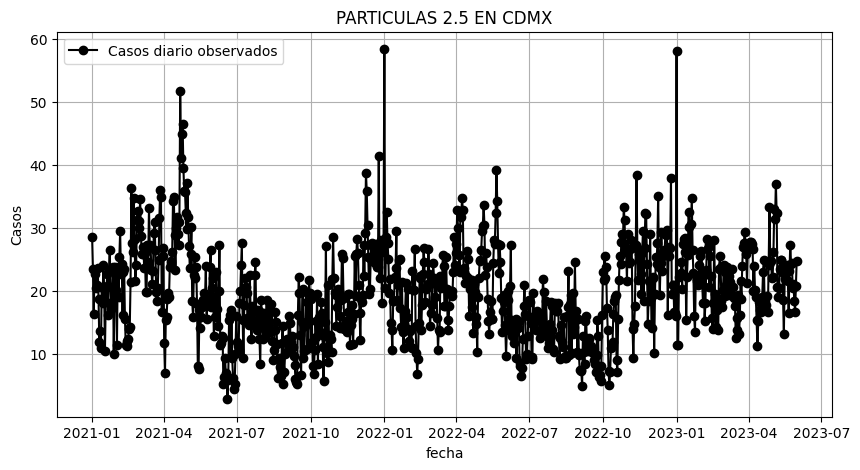

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    df["fecha"],
    df["casos_diario_PM2.5"],
    marker="o",
    label="Casos diario observados",
    color='black'
)

plt.xlabel("fecha")
plt.ylabel("Casos")
plt.title("PARTICULAS 2.5 EN CDMX")
plt.xticks()
plt.legend()
plt.grid()

plt.show()

Como podemos observas durante le periodo de del año 2021 al 2023 donde mas se las particulas PM2.5 las fechas mas afectadas son al inicio del año esto se puede deber a muchas causas como las festividades de año nuevo, donde la muchas familias Mexicanas salen a tronar cohetes, queman sillones para hacer una fogata, o incluso el inmenso translado que hacen en automoviles y otros medios de transpotes para poder pasar estos dias con sus familiares. Posteriormente despues de estas fechas como baja pero al a mitad del año empieza a subir denuevo ya que empiezan otras fechas importantes como el 15 de septiembre, dia de muestro etc. donde de igual manera festejan de una manera similar al año nuevo.

In [ ]:
df["lag_1"] = df["casos_diario_PM2.5"].shift(1) # Rezagos
df["lag_2"] = df["casos_diario_PM2.5"].shift(2)
df["lag_3"] = df["casos_diario_PM2.5"].shift(3)

df["promedio_movil_3"] = df["casos_diario_PM2.5"].rolling(window=3).mean() # Promedios móviles
df["promedio_movil_5"] = df["casos_diario_PM2.5"].rolling(window=5).mean()

df["cambio_diario"] = df["casos_diario_PM2.5"].diff() # Cambio semanal

df["casos_siguiente_dia"] = df["casos_diario_PM2.5"].shift(-1) # Variable objetivo

df.head()

,fecha,CO,NO,NO2,NOX,O3,PM10,PM25,SO2,casos_diario_PM2.5,lag_1,lag_2,lag_3,promedio_movil_3,promedio_movil_5,cambio_diario,casos_siguiente_dia
0,2021-01-01,0.417782,5.712963,16.977273,23.261574,29.765494,54.327273,28.594855,1.125912,28.594855,NaN,NaN,NaN,NaN,NaN,NaN,23.465409
1,2021-01-02,0.515087,14.289894,26.782609,42.090426,33.647969,48.196481,23.465409,1.725000,23.465409,28.594855,NaN,NaN,NaN,NaN,-5.129447,16.423676
2,2021-01-03,0.446905,12.328571,22.773256,35.714286,28.135823,39.091988,16.423676,1.548983,16.423676,23.465409,28.594855,NaN,22.827980,NaN,-7.041733,23.160000
3,2021-01-04,0.580398,22.323040,31.306483,54.418052,28.824532,52.486239,23.160000,3.410019,23.160000,16.423676,23.465409,28.594855,21.016362,NaN,6.736324,22.694444
4,2021-01-05,0.533105,19.386091,29.376218,49.995204,28.941374,55.916667,22.694444,5.251366,22.694444,23.160000,16.423676,23.465409,20.759373,22.867677,-0.465556,20.473214


In [ ]:
columnas_modelo = [
    "fecha",
    "casos_diario_PM2.5",
    "lag_1",
    "lag_2",
    "lag_3",
    "promedio_movil_3",
    "promedio_movil_5",
    "cambio_diario",
    "casos_siguiente_dia"
]

df_modelo = df[columnas_modelo].dropna().reset_index(drop=True)

df_modelo.head()

,fecha,casos_diario_PM2.5,lag_1,lag_2,lag_3,promedio_movil_3,promedio_movil_5,cambio_diario,casos_siguiente_dia
0,2021-01-05,22.694444,23.160000,16.423676,23.465409,20.759373,22.867677,-0.465556,20.473214
1,2021-01-06,20.473214,22.694444,23.160000,16.423676,22.109220,21.243349,-2.221230,21.035821
2,2021-01-07,21.035821,20.473214,22.694444,23.160000,21.401160,20.757431,0.562607,23.665653
3,2021-01-08,23.665653,21.035821,20.473214,22.694444,21.724896,22.205827,2.629833,18.708333
4,2021-01-09,18.708333,23.665653,21.035821,20.473214,21.136603,21.315493,-4.957320,11.921922


In [ ]:
variables_predictoras = [
    "casos_diario_PM2.5",
    "lag_1",
    "lag_2",
    "lag_3",
    "promedio_movil_3",
    "promedio_movil_5",
    "cambio_diario"
]

X = df_modelo[variables_predictoras]
y = df_modelo["casos_siguiente_dia"]

print(X.head())
print(y.head())

   casos_diario_PM2.5      lag_1      lag_2      lag_3  promedio_movil_3  \
0           22.694444  23.160000  16.423676  23.465409         20.759373   
1           20.473214  22.694444  23.160000  16.423676         22.109220   
2           21.035821  20.473214  22.694444  23.160000         21.401160   
3           23.665653  21.035821  20.473214  22.694444         21.724896   
4           18.708333  23.665653  21.035821  20.473214         21.136603   

   promedio_movil_5  cambio_diario  
0         22.867677      -0.465556  
1         21.243349      -2.221230  
2         20.757431       0.562607  
3         22.205827       2.629833  
4         21.315493      -4.957320  
0    20.473214
1    21.035821
2    23.665653
3    18.708333
4    11.921922
Name: casos_siguiente_dia, dtype: float64


Para este Proyecto se manejara dos tipos de problema tanto para regresion como clasificacion tanto de regresion como  de clasificacion

In [ ]:
n = len(df_modelo)

n_train = int(0.7 * n)

df_train = df_modelo.iloc[:n_train].copy()
df_test = df_modelo.iloc[n_train:].copy()

X_train = df_train[variables_predictoras]
y_train = df_train["casos_siguiente_dia"]

X_test = df_test[variables_predictoras]
y_test = df_test["casos_siguiente_dia"]

print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

Tamaño entrenamiento: (613, 7)
Tamaño prueba: (263, 7)


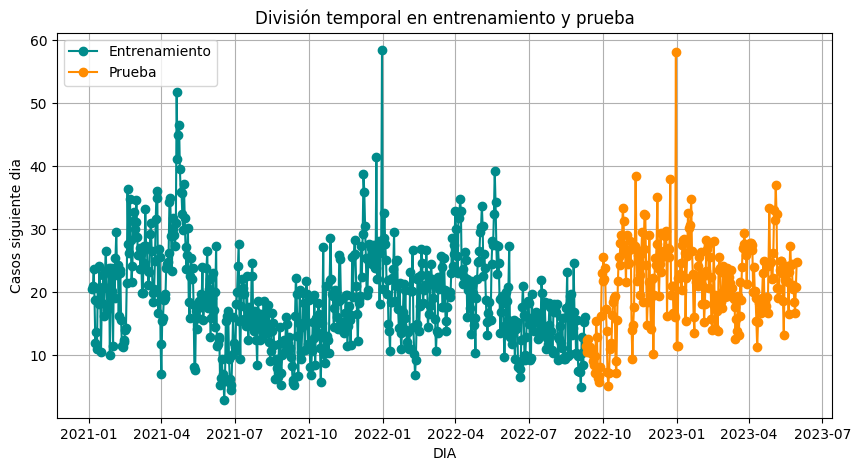

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    df_train["fecha"],
    df_train["casos_siguiente_dia"],
    marker="o",
    label="Entrenamiento",
    color="darkcyan"
)

plt.plot(
    df_test["fecha"],
    df_test["casos_siguiente_dia"],
    marker="o",
    label="Prueba",
    color="darkorange"
)

plt.xlabel("DIA")
plt.ylabel("Casos siguiente dia")
plt.title("División temporal en entrenamiento y prueba")
plt.xticks()
plt.legend()
plt.grid()

plt.show()

In [ ]:
def calcular_metricas(y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))

    return mae, rmse

In [ ]:
df_test["pred_naive"] = df_test["casos_diario_PM2.5"]
mae_naive, rmse_naive = calcular_metricas(
    y_test,
    df_test["pred_naive"]
)

print("Modelo ingenuo")
print("MAE:", mae_naive)
print("RMSE:", rmse_naive)

Modelo ingenuo
MAE: 4.106074345901035
RMSE: 6.254379462409963


In [ ]:
modelo_lr = LinearRegression()

modelo_lr.fit(X_train, y_train)

pred_lr = modelo_lr.predict(X_test)

# Evitar predicciones negativas
pred_lr = np.maximum(pred_lr, 0)

mae_lr, rmse_lr = calcular_metricas(y_test, pred_lr)

print("Regresión lineal")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)

Regresión lineal
MAE: 3.894464673454348
RMSE: 5.5462100359014075


In [ ]:
modelo_arbol = DecisionTreeRegressor(
    max_depth=3,
    min_samples_leaf=3,
    random_state=42
)

modelo_arbol.fit(X_train, y_train)

pred_arbol = modelo_arbol.predict(X_test)

pred_arbol = np.maximum(pred_arbol, 0)

mae_arbol, rmse_arbol = calcular_metricas(y_test, pred_arbol)

print("Árbol de decisión")
print("MAE:", mae_arbol)
print("RMSE:", rmse_arbol)

Árbol de decisión
MAE: 4.22329354180815
RMSE: 5.726959798079991


In [ ]:
modelo_rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=4,
    min_samples_leaf=3,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

pred_rf = np.maximum(pred_rf, 0)

mae_rf, rmse_rf = calcular_metricas(y_test, pred_rf)

print("Random Forest")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)

Random Forest
MAE: 4.0264188196915445
RMSE: 5.531748262364626


In [ ]:
df_metricas = pd.DataFrame({
    "modelo": [
        "Naive",
        "Regresión lineal",
        "Árbol de decisión",
        "Random Forest"
    ],
    "MAE": [
        mae_naive,
        mae_lr,
        mae_arbol,
        mae_rf
    ],
    "RMSE": [
        rmse_naive,
        rmse_lr,
        rmse_arbol,
        rmse_rf
    ]
})

df_metricas.sort_values("RMSE")

,modelo,MAE,RMSE
3,Random Forest,4.026419,5.531748
1,Regresión lineal,3.894465,5.546210
2,Árbol de decisión,4.223294,5.726960
0,Naive,4.106074,6.254379


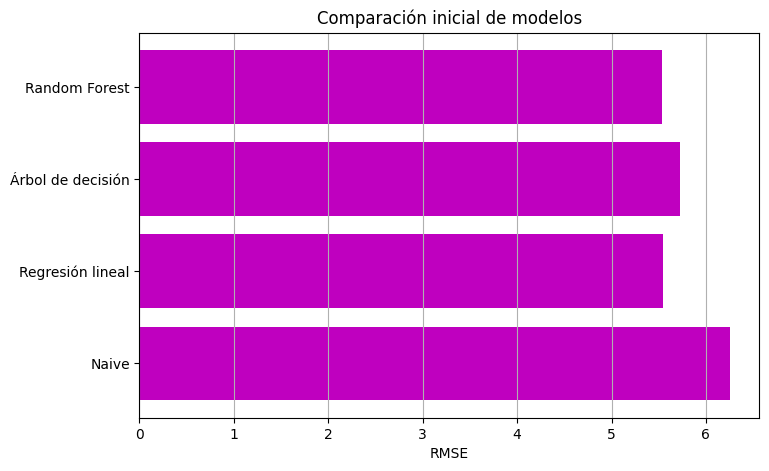

In [ ]:
plt.figure(figsize=(8, 5))

plt.barh(
    df_metricas["modelo"],
    df_metricas["RMSE"], color='m'
)

plt.xlabel("RMSE")
plt.title("Comparación inicial de modelos")
plt.grid(axis="x")

plt.show()

In [ ]:
df_test["pred_lr"] = pred_lr
df_test["pred_arbol"] = pred_arbol
df_test["pred_rf"] = pred_rf

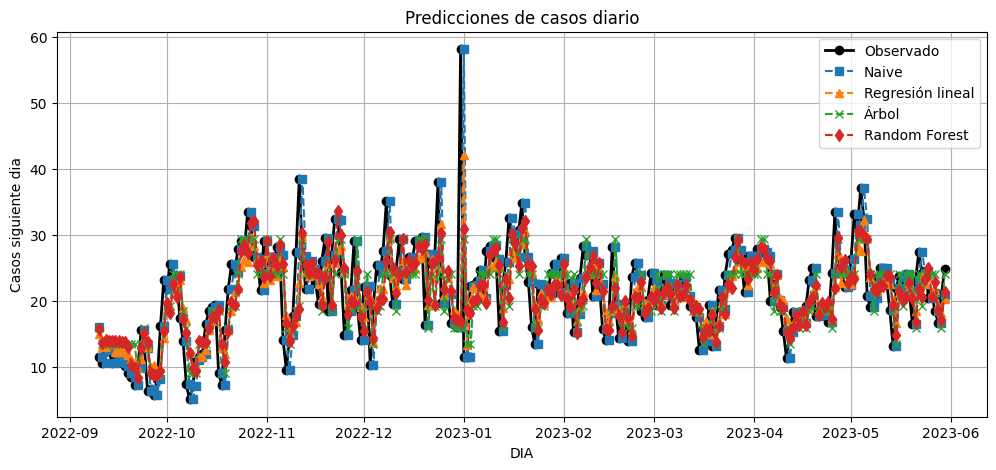

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    df_test["fecha"],
    df_test["casos_siguiente_dia"],
    marker="o",
    label="Observado", color = 'black', lw=2
)

plt.plot(
    df_test["fecha"],
    df_test["pred_naive"],
    marker="s",
    linestyle="--",
    label="Naive"
)

plt.plot(
    df_test["fecha"],
    df_test["pred_lr"],
    marker="^",
    linestyle="--",
    label="Regresión lineal"
)

plt.plot(
    df_test["fecha"],
    df_test["pred_arbol"],
    marker="x",
    linestyle="--",
    label="Árbol"
)

plt.plot(
    df_test["fecha"],
    df_test["pred_rf"],
    marker="d",
    linestyle="--",
    label="Random Forest"
)

plt.xlabel("DIA")
plt.ylabel("Casos siguiente dia")
plt.title("Predicciones de casos diario")
plt.legend()
plt.grid()

plt.show()

Como podemos observar Random Forest y Regresion lineal son muy parecido respecto a la prediccion sin embargo al analizar detalladamente Naive se ajusta de major manera siguiendo de mejor manera a los datos reales.